# pyNanoMatBuilder ↔ abTEM coupling: High-resolution transmission electron microscopy 

High-resolution transmission electron microscopy (HRTEM) is a powerful experimental technique for studying materials at the atomic scale.
This notebook is a minimal tutorial showing how to build a nanoparticle with **pyNanoMatBuilder**, place it on an amorphous-carbon TEM grid, and simulate a single HRTEM image of it with **abTEM**. 



This is a simple, one-structure coupling — one NP, one pose, one image per call. For automatic image-database generation (many compounds/shapes/sizes/orientations), a new notebook will be uploaded soon.

**Required environment / kernel**: `abtem_env` (dedicated — do not reuse a general-purpose environment)


Create your environment, for example with conda:

```bash
conda create -n abtem_env python=3.11 -y
conda activate abtem_env
```

Install the dependencies:

```bash
pip install -r requirements-abtem.txt -e .
```

Register the kernel if not already done
```bash
python -m ipykernel install --user --name abtem_env --display-name "Python (abtem_env)"
```






`requirements-abtem.txt` pins known-working versions of the tricky dependencies (numpy, abTEM, ase, numba...). See that file for details and version notes.

Make sure this notebook is running on the **abtem_env** kernel before executing the cells below.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
from pyNanoMatBuilder import platonicNPs as pNP

## 2. Build a nanoparticle with pyNanoMatBuilder

**First build the NP with the usual pyNanoMatBuilder API** — any shape class works (`platonicNPs`, `archimedeanNPs`, `crystalNPs.Crystal` Wulff shapes...). The only requirement is `postAnalyzis=True`, so that the convex-hull facets are available for the placement, and a circumscribed-sphere diameter **smaller than the substrate** (5 or 10 nm laterally).

In [2]:
# Gold icosahedron — any other pyNanoMatBuilder shape class works too
AuNP = pNP.regIco(element='Au', Rnn=2.885, nShell=5,
                  postAnalyzis=True, thresholdCoreSurface=1,
                  skipSymmetryAnalyzis=True, aseView=False, noOutput=True)

print(f"{len(AuNP.NP)} atoms, circumscribed diameter = "
      f"{AuNP.radiusCircumscribedSphere * 2 / 10:.2f} nm")

561 atoms, circumscribed diameter = 2.74 nm


## 3. Compute the HRTEM image


You can either use the abTEM API to build an HRTEM image step by step, as shown in the abTEM quickstart tutorial: https://abtem.readthedocs.io/en/latest/user_guide/examples/notebooks/hrtem_quickstart.html#examples-hrtem-quickstart. Alternatively, you can use our `hrtem_image` function, which reproduces the same workflow in fewer steps.

This class is built on **abTEM** (<https://abtem.readthedocs.io/en/latest/intro.html>), an open-source package for simulating HRTEM experiments. abTEM computes the exit electron wave function after the electron beam passes through the sample using a multislice algorithm. This wave function encodes structural information about the sample. However, realistic microscope effects such as lens aberrations, detector response, and noise cause information loss and image degradation in the final HRTEM image. The `hrtem_image` function applies these effects to produce simulated images that closely match experimental conditions.

The `hrtem_image()` function handles both steps automatically:

- **Place the NP on the carbon substrate** — takes a nanoparticle built with the usual pyNanoMatBuilder API (the instance, or directly its `.NP` ASE `Atoms` object), places it on a flat area of the amorphous-carbon substrate shipped with the package (5×5 or 10×10 nm), and optionally writes the full XYZ file. The only constraint: **the NP must be smaller than the substrate**.
- **Compute the HRTEM image** — runs the abTEM multislice pipeline (frozen phonons, CTF at Scherzer defocus, partial coherence, Poisson shot noise, detector MTF) on that structure and produces one HRTEM image.


### 3.1 Place the NP on the carbon substrate

Control where and how the NP sits on the carbon substrate:




- `tolerance`: Gap between the NP and carbon surface (Å)


<div class="intro">
<figure style="text-align:center;">
  <img src="pyNanoMatBuilder/resources/figs/hrtem/hrtem_tolerance.png" alt="PtStar_2h" style="width:600px;">
</figure>
</div>


- `angle_xy`: In-plane (xy) rotation of the NP around the vertical axis (degrees)


<div class="intro">
<figure style="text-align:center;">
  <img src="pyNanoMatBuilder/resources/figs/hrtem/hrtem_angle_xy.png" alt="PtStar_2h" style="width:600px;">
</figure>
</div>


- `tilt`: Tilt (z) to simulate imperfect contact (degrees)

<div class="intro">
<figure style="text-align:center;">
  <img src="pyNanoMatBuilder/resources/figs/hrtem/hrtem_tilt.png" alt="PtStar_2h" style="width:600px;">
</figure>
</div>

- `substrate_size`: Lateral size (xy) of the amorphous-carbon substrate (Å)
- `substrate_thickness`: Thickness (z) of the substrate (Å)


In [3]:
# Placement parameters — grouped in a dict (all optional; these override the defaults)
placement = dict(
    substrate_size=50,        # lateral substrate size, Å (50 or 100)
    substrate_thickness=40,   # carbon slab kept for the simulation, Å
    tolerance=1,              # gap between the NP and the carbon surface, Å
    angle_xy=50,              # in-plane rotation of the NP, degrees
    tilt=0,                   # tilt off the substrate plane, degrees
)

### 3.2 Compute the HRTEM image

The class exposes the most physically relevant microscope parameters (*electron energy, sampling, frozen-phonon configurations, substrate thickness, and detector characteristics*). For the complete set of tunable parameters, consult the class documentation. Even if you use this class, we still recommend the abTEM tutorial for deeper understanding of the microscope parameters (same link).

**Note:** In addition to abTEM's standard parameters, we have added custom parameters for Poisson noise and MTF (modulation transfer function) coefficients (`c1`, `c2`, `c3`). These parameters significantly affect the final image quality:
- **Poisson noise** — simulates shot noise from the electron detector, directly impacting the signal-to-noise ratio
- **MTF coefficients** — determine how much contrast from the original sample structure is preserved by the detector



In [4]:
# Example of microscope parameters — grouped in a dict (all optional; these override the defaults)
microscope = dict(
    energy=200e3,             # Electron beam energy in eV
    sampling=0.1,             # Å per grid point (impacts the computation time)
    phonon_config=8,          # frozen-phonon configurations
    slice_thickness=1.0,      # Thickness of each slice in Å
    semiangle_cutoff_value=30,# Objective aperture semiangle cutoff in mrad.
    dose_poisson_noise=1e4,   # Dose for Poisson noise simulation (electrons per Å²)
)

In [5]:
img = AuNP.hrtem_image(**placement, **microscope,
                        device='cpu',
                          output_xyz="coords/AuNP_hrtem.xyz", # if you want to save the NP+substrate coordinates
                            noOutput=False)

NP: 561 atoms, circumscribed diameter = 2.74 nm
Substrate: 5x5 nm amorphous carbon (12161 atoms)
Placement: angle_xy = 50 deg, tilt = 0 deg, clearance = 1 A
XYZ file written: coords/AuNP_hrtem.xyz
Simulation cell: 49 x 49 x 64.3 A, 10770 atoms


tasks:  68%|######8   | 17/25 [00:05<00:02,  3.39it/s]

defocus (Scherzer) = -54.86 A, focal_spread = 17.50 A


<Axes: xlabel='x (Å)', ylabel='y (Å)'>

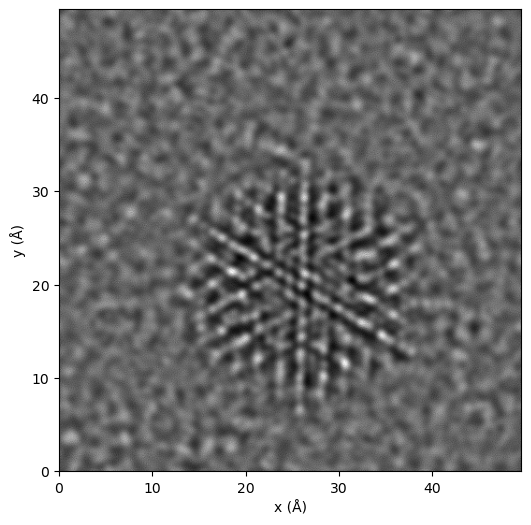

In [6]:
img.show()

#### Fast Fourier transform (FFT) of the image/Electron diffraction

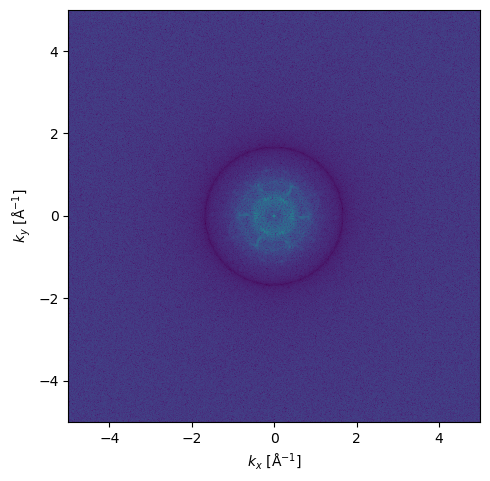

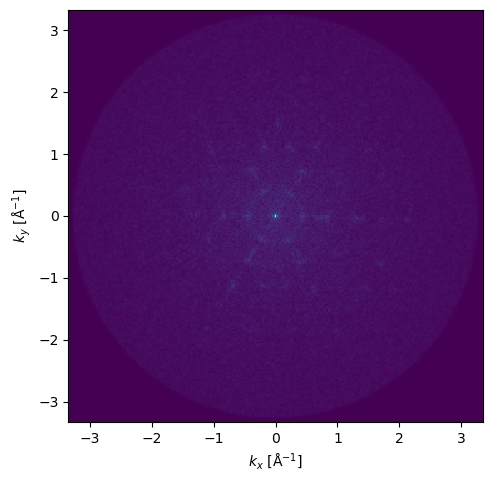

In [10]:


img.diffractogram().show(power=0.2)      # FFT
img.exit_wave.diffraction_patterns().show(power=0.2)    # diffraction électronique (bonus)

In [11]:
print(img.metadata)

{'sampling_A': 0.1, 'energy_eV': 200000.0, 'phonon_config': 8, 'sigmas_A': 0.1, 'slice_thickness_A': 1.0, 'Cs_value_A': -80000.0, 'defocus_C10_A': np.float64(-54.859099865741655), 'C12_A': 0.0, 'phi12_rad': 0.0, 'Cc_value_A': 10000000.0, 'energy_spread_eV': 0.35, 'focal_spread_A': 17.5, 'semiangle_cutoff_mrad': 30, 'mtf_c1': -0.6, 'mtf_c2': 0.1, 'mtf_c3': 1.0, 'mtf_clip': False, 'dose_poisson_noise_e-A-2': 10000.0, 'substrate_thickness_A': 40, 'device': 'cpu'}


#### Optional: save the PNG (+ a CSV with all the simulation parameters)


In [12]:
img.save('coords/Au_hrtem.png', metadata=True)


Metadata written: coords\Au_hrtem_metadata.csv
Image written: coords/Au_hrtem.png
